In [ ]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 12


In [ ]:
#Load Data
df = pd.read_csv("../../data/fraud/creditcard.csv")

print("Dataset Shape:", df.shape)
print("Total Transactions:", len(df))
print("Total Features:", df.shape[1])
print("Fraud Cases:", df["Class"].sum())
print("Legitimate Cases:", (df["Class"] == 0).sum())
print("Fraud Percentage:", round(df["Class"].mean() * 100, 4), "%")
print("Date Range (Time in seconds):", df["Time"].min(), "to", df["Time"].max())
print("Time span in hours:", round(df["Time"].max() / 3600, 2))

Dataset Shape: (284807, 31)
Total Transactions: 284807
Total Features: 31
Fraud Cases: 492
Legitimate Cases: 284315
Fraud Percentage: 0.1727 %
Date Range (Time in seconds): 0.0 to 172792.0
Time span in hours: 48.0


In [ ]:
#checking the data quality
print("DATA QUALITY REPORT")
print()

print("Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  No missing values found across all", df.shape[1], "columns")
else:
    print(missing[missing > 0])

print()
print("Duplicate Rows:")
dupes = df.duplicated().sum()
print(f"  {dupes} duplicate rows found")
if dupes > 0:
    print("  Removing duplicates...")
    df = df.drop_duplicates()
    print(f"  Dataset shape after removing duplicates: {df.shape}")

print()
print("Data Types:")
print(df.dtypes.value_counts())

print()
print("Negative Values in Amount column:")
neg_amount = (df["Amount"] < 0).sum()
print(f"  {neg_amount} negative transaction amounts found")

print()
print("Zero Amount Transactions:")
zero_amount = (df["Amount"] == 0).sum()
zero_fraud = df[(df["Amount"] == 0) & (df["Class"] == 1)].shape[0]
print(f"  Total zero-amount transactions: {zero_amount}")
print(f"  Zero-amount fraud transactions: {zero_fraud}")
print(f"  Zero-amount fraud rate: {round(zero_fraud/zero_amount*100, 2)}%")

DATA QUALITY REPORT

Missing Values:
  No missing values found across all 31 columns

Duplicate Rows:
  1081 duplicate rows found
  Removing duplicates...
  Dataset shape after removing duplicates: (283726, 31)

Data Types:
float64    30
int64       1
Name: count, dtype: int64

Negative Values in Amount column:
  0 negative transaction amounts found

Zero Amount Transactions:
  Total zero-amount transactions: 1808
  Zero-amount fraud transactions: 25
  Zero-amount fraud rate: 1.38%


CLASS DISTRIBUTION ANALYSIS

  Legitimate transactions : 283,253  (99.8333%)
  Fraud transactions      : 473  (0.1667%)
  Imbalance ratio         : 598.8:1  (legitimate to fraud)

  This extreme imbalance is why standard accuracy is misleading.
  A model predicting ALL transactions as legitimate gets 99.83% accuracy
  but catches ZERO fraud. We must use AUC-ROC, F1, Precision, Recall.


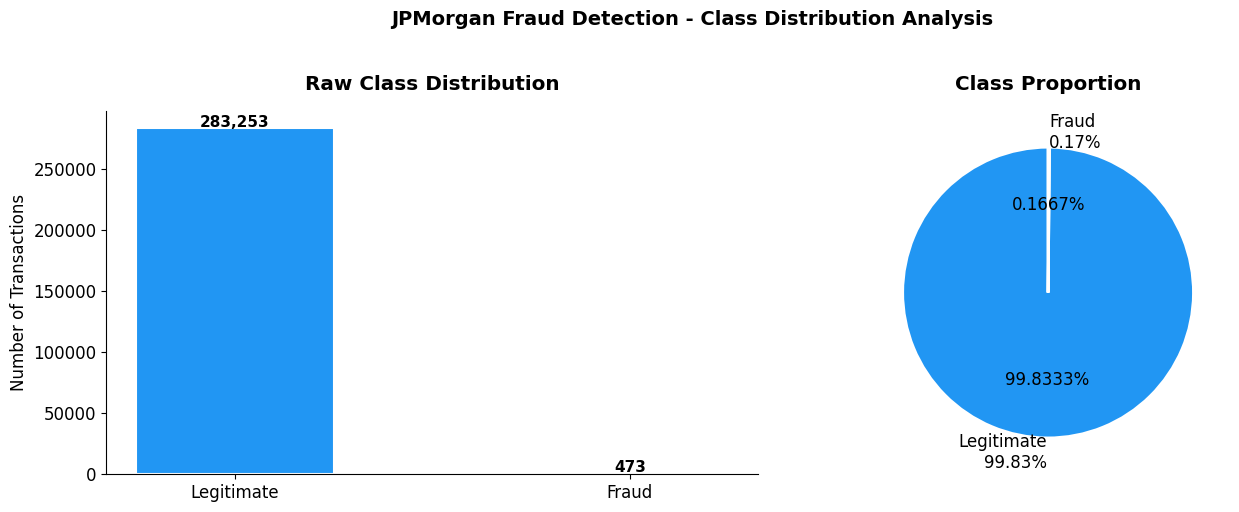

In [ ]:
#class distribution analysis
print("CLASS DISTRIBUTION ANALYSIS")
print()

legit = (df["Class"] == 0).sum()
fraud = (df["Class"] == 1).sum()
total = len(df)

print(f"  Legitimate transactions : {legit:,}  ({round(legit/total*100, 4)}%)")
print(f"  Fraud transactions      : {fraud:,}  ({round(fraud/total*100, 4)}%)")
print(f"  Imbalance ratio         : {round(legit/fraud, 1)}:1  (legitimate to fraud)")
print()
print("  This extreme imbalance is why standard accuracy is misleading.")
print("  A model predicting ALL transactions as legitimate gets 99.83% accuracy")
print("  but catches ZERO fraud. We must use AUC-ROC, F1, Precision, Recall.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(["Legitimate", "Fraud"], [legit, fraud], 
            color=["#2196F3", "#F44336"], width=0.5, edgecolor="white", linewidth=1.5)
axes[0].set_title("Raw Class Distribution", fontweight="bold", pad=15)
axes[0].set_ylabel("Number of Transactions")
for i, v in enumerate([legit, fraud]):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold", fontsize=11)

axes[1].pie([legit, fraud], labels=["Legitimate\n99.83%", "Fraud\n0.17%"],
            colors=["#2196F3", "#F44336"], autopct="%1.4f%%",
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Class Proportion", fontweight="bold", pad=15)

plt.suptitle("JPMorgan Fraud Detection - Class Distribution Analysis", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../../notebooks/fraud/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

TRANSACTION AMOUNT ANALYSIS

Legitimate Transactions - Amount Statistics:
  Mean   : $88.41
  Median : $22.00
  Std Dev: $250.38
  Min    : $0.00
  Max    : $25691.16
  75th % : $77.46
  95th % : $365.00
  99th % : $1018.06

Fraud Transactions - Amount Statistics:
  Mean   : $123.87
  Median : $9.82
  Std Dev: $260.21
  Min    : $0.00
  Max    : $2125.87
  75th % : $105.89
  95th % : $655.82
  99th % : $1364.14

Key Insight:
  Fraud median ($9.82) vs Legitimate median ($22.00)
  Fraudsters tend to make SMALLER transactions to avoid detection thresholds


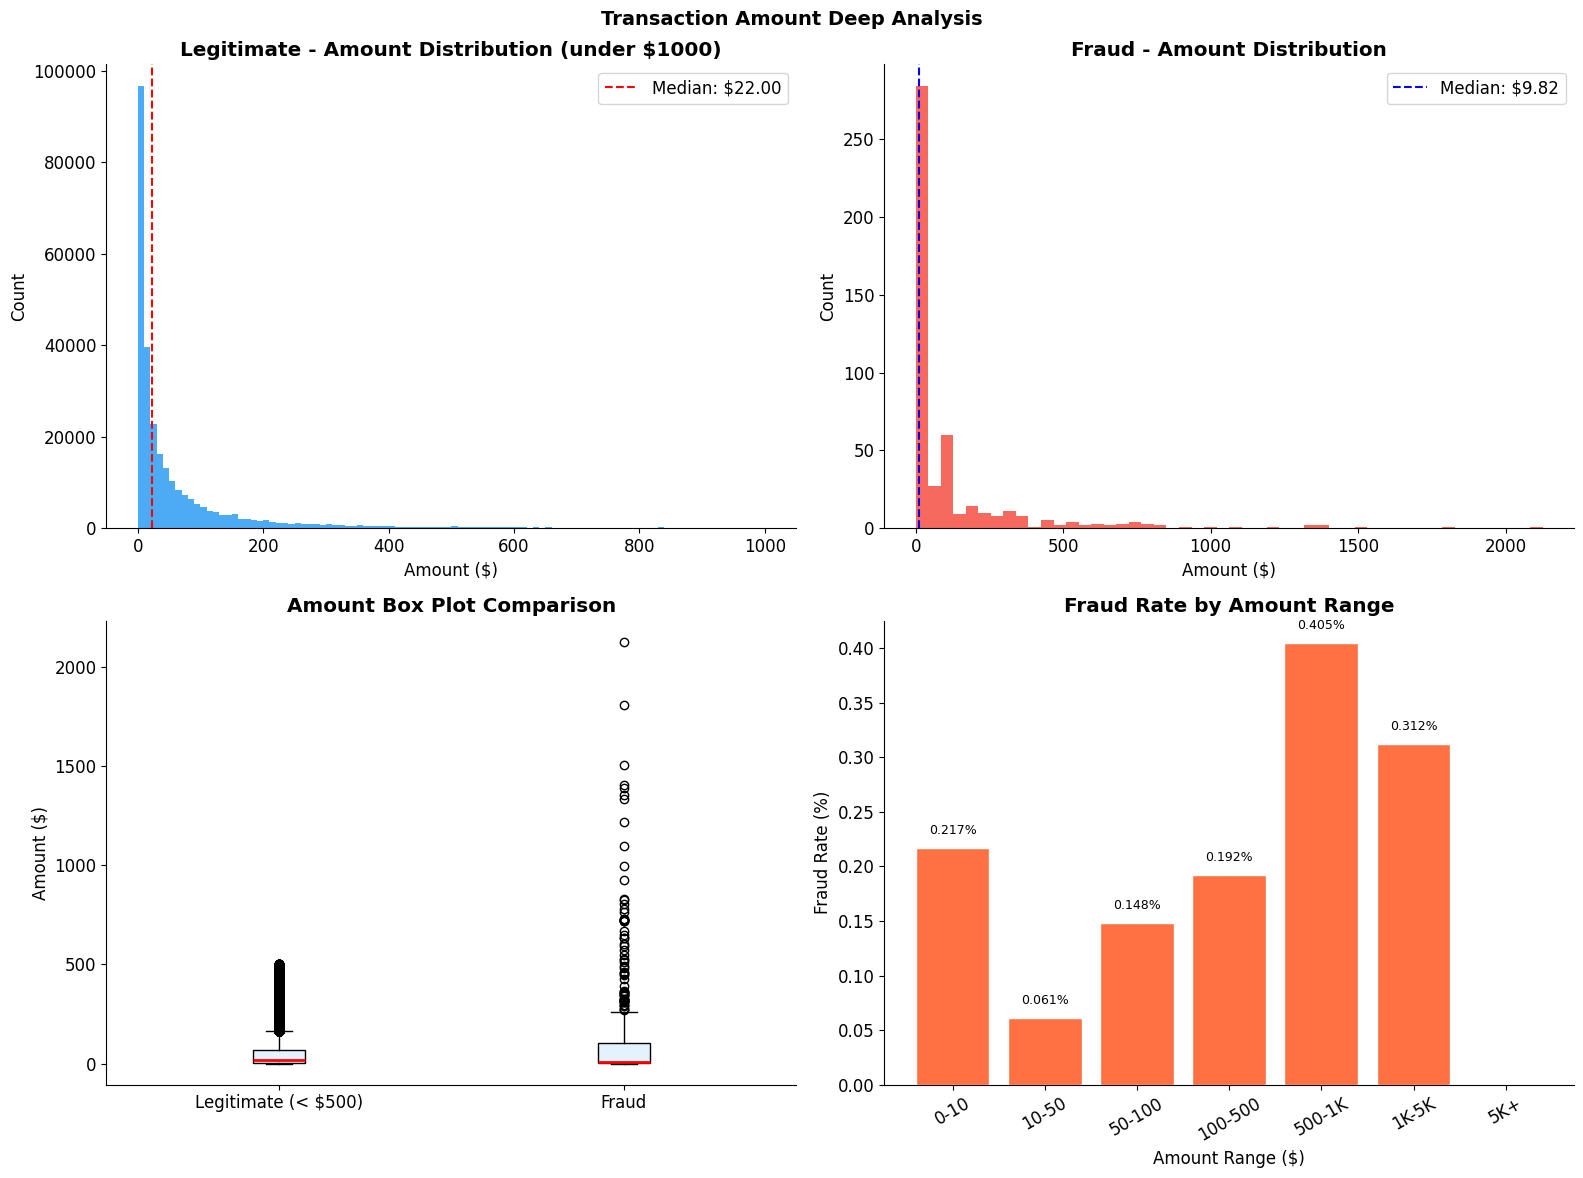

In [6]:
#Transaction Amount Deep Analysis
print("TRANSACTION AMOUNT ANALYSIS")
print()

legit_amounts = df[df["Class"] == 0]["Amount"]
fraud_amounts = df[df["Class"] == 1]["Amount"]

print("Legitimate Transactions - Amount Statistics:")
print(f"  Mean   : ${legit_amounts.mean():.2f}")
print(f"  Median : ${legit_amounts.median():.2f}")
print(f"  Std Dev: ${legit_amounts.std():.2f}")
print(f"  Min    : ${legit_amounts.min():.2f}")
print(f"  Max    : ${legit_amounts.max():.2f}")
print(f"  75th % : ${legit_amounts.quantile(0.75):.2f}")
print(f"  95th % : ${legit_amounts.quantile(0.95):.2f}")
print(f"  99th % : ${legit_amounts.quantile(0.99):.2f}")

print()
print("Fraud Transactions - Amount Statistics:")
print(f"  Mean   : ${fraud_amounts.mean():.2f}")
print(f"  Median : ${fraud_amounts.median():.2f}")
print(f"  Std Dev: ${fraud_amounts.std():.2f}")
print(f"  Min    : ${fraud_amounts.min():.2f}")
print(f"  Max    : ${fraud_amounts.max():.2f}")
print(f"  75th % : ${fraud_amounts.quantile(0.75):.2f}")
print(f"  95th % : ${fraud_amounts.quantile(0.95):.2f}")
print(f"  99th % : ${fraud_amounts.quantile(0.99):.2f}")

print()
print("Key Insight:")
print(f"  Fraud median (${fraud_amounts.median():.2f}) vs Legitimate median (${legit_amounts.median():.2f})")
if fraud_amounts.median() < legit_amounts.median():
    print("  Fraudsters tend to make SMALLER transactions to avoid detection thresholds")
else:
    print("  Fraudsters tend to make LARGER transactions")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(legit_amounts[legit_amounts < 1000], bins=100, 
                color="#2196F3", alpha=0.8, edgecolor="none")
axes[0, 0].set_title("Legitimate - Amount Distribution (under $1000)", fontweight="bold")
axes[0, 0].set_xlabel("Amount ($)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].axvline(legit_amounts.median(), color="red", linestyle="--", 
                    label=f"Median: ${legit_amounts.median():.2f}")
axes[0, 0].legend()

axes[0, 1].hist(fraud_amounts, bins=50, color="#F44336", alpha=0.8, edgecolor="none")
axes[0, 1].set_title("Fraud - Amount Distribution", fontweight="bold")
axes[0, 1].set_xlabel("Amount ($)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].axvline(fraud_amounts.median(), color="blue", linestyle="--",
                    label=f"Median: ${fraud_amounts.median():.2f}")
axes[0, 1].legend()

axes[1, 0].boxplot([legit_amounts[legit_amounts < 500].values, fraud_amounts.values],
                    labels=["Legitimate (< $500)", "Fraud"],
                    patch_artist=True,
                    boxprops=dict(facecolor="#E3F2FD"),
                    medianprops=dict(color="red", linewidth=2))
axes[1, 0].set_title("Amount Box Plot Comparison", fontweight="bold")
axes[1, 0].set_ylabel("Amount ($)")

amount_bins = [0, 10, 50, 100, 500, 1000, 5000, 30000]
labels = ["0-10", "10-50", "50-100", "100-500", "500-1K", "1K-5K", "5K+"]
legit_binned = pd.cut(legit_amounts, bins=amount_bins, labels=labels).value_counts().sort_index()
fraud_binned = pd.cut(fraud_amounts, bins=amount_bins, labels=labels).value_counts().sort_index()
fraud_rate_by_bin = (fraud_binned / (fraud_binned + legit_binned) * 100).fillna(0)

bars = axes[1, 1].bar(labels, fraud_rate_by_bin.values, color="#FF7043", edgecolor="white")
axes[1, 1].set_title("Fraud Rate by Amount Range", fontweight="bold")
axes[1, 1].set_xlabel("Amount Range ($)")
axes[1, 1].set_ylabel("Fraud Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, fraud_rate_by_bin.values):
    if val > 0:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f"{val:.3f}%", ha="center", va="bottom", fontsize=9)

plt.suptitle("Transaction Amount Deep Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/amount_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

TIME PATTERN ANALYSIS

The Time column represents seconds elapsed since first transaction in dataset
Dataset covers 48.0 hours of transactions

Transactions per day:
             total  frauds
day_number                
1           144236     272
2           139490     201

Peak fraud hour: 2:00
Fraud rate at peak hour: 1.4510%


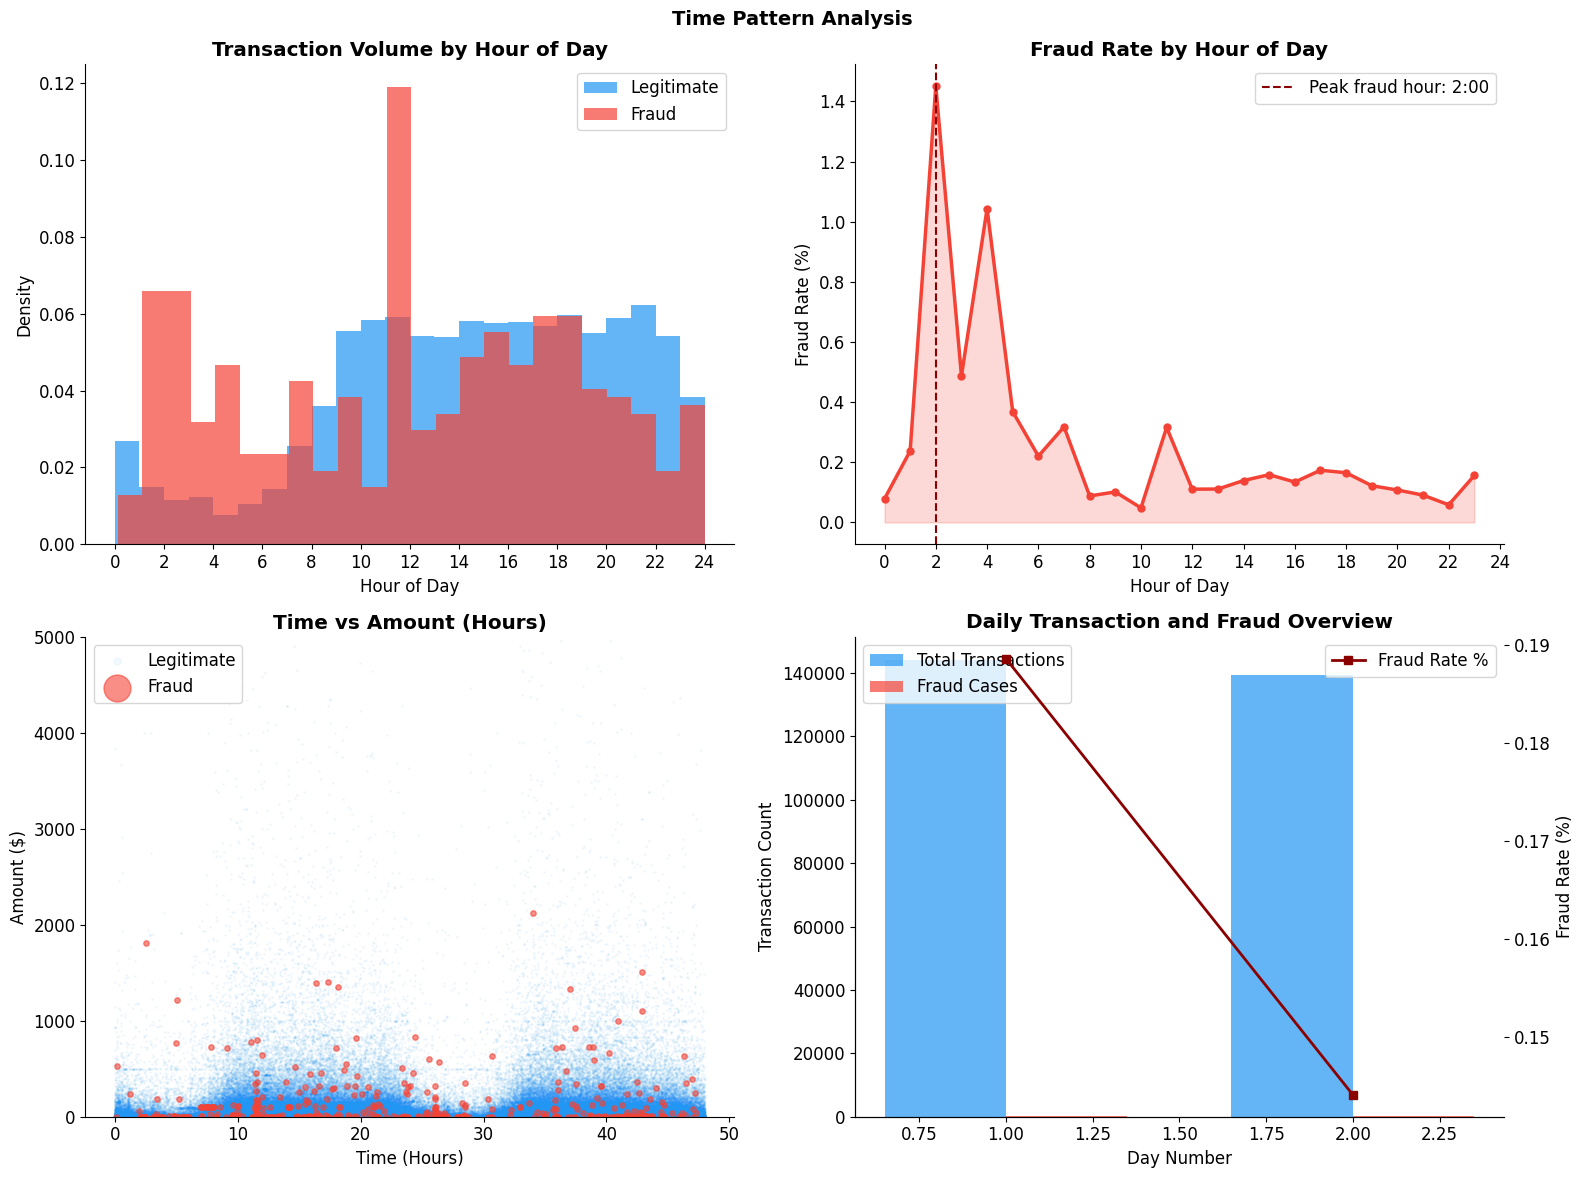

In [7]:
#Time pattern Analysis

print("TIME PATTERN ANALYSIS")
print()
print("The Time column represents seconds elapsed since first transaction in dataset")
print("Dataset covers", round(df["Time"].max() / 3600, 1), "hours of transactions")
print()

df["hour_of_day"] = (df["Time"] / 3600) % 24
df["day_number"] = (df["Time"] / 3600 / 24).astype(int) + 1

print("Transactions per day:")
print(df.groupby("day_number")["Class"].agg(["count", "sum"]).rename(
    columns={"count": "total", "sum": "frauds"}))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

legit_hours = df[df["Class"] == 0]["hour_of_day"]
fraud_hours = df[df["Class"] == 1]["hour_of_day"]

axes[0, 0].hist(legit_hours, bins=24, color="#2196F3", alpha=0.7, label="Legitimate", density=True)
axes[0, 0].hist(fraud_hours, bins=24, color="#F44336", alpha=0.7, label="Fraud", density=True)
axes[0, 0].set_title("Transaction Volume by Hour of Day", fontweight="bold")
axes[0, 0].set_xlabel("Hour of Day")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()
axes[0, 0].set_xticks(range(0, 25, 2))

hourly_fraud_rate = df.groupby(df["hour_of_day"].astype(int))["Class"].mean() * 100
axes[0, 1].plot(hourly_fraud_rate.index, hourly_fraud_rate.values, 
                color="#F44336", linewidth=2.5, marker="o", markersize=5)
axes[0, 1].fill_between(hourly_fraud_rate.index, hourly_fraud_rate.values, alpha=0.2, color="#F44336")
axes[0, 1].set_title("Fraud Rate by Hour of Day", fontweight="bold")
axes[0, 1].set_xlabel("Hour of Day")
axes[0, 1].set_ylabel("Fraud Rate (%)")
axes[0, 1].set_xticks(range(0, 25, 2))

peak_fraud_hour = hourly_fraud_rate.idxmax()
axes[0, 1].axvline(peak_fraud_hour, color="darkred", linestyle="--", 
                    label=f"Peak fraud hour: {peak_fraud_hour}:00")
axes[0, 1].legend()

axes[1, 0].scatter(df[df["Class"] == 0]["Time"] / 3600, 
                    df[df["Class"] == 0]["Amount"],
                    alpha=0.05, color="#2196F3", label="Legitimate", s=1)
axes[1, 0].scatter(df[df["Class"] == 1]["Time"] / 3600,
                    df[df["Class"] == 1]["Amount"],
                    alpha=0.6, color="#F44336", label="Fraud", s=15)
axes[1, 0].set_title("Time vs Amount (Hours)", fontweight="bold")
axes[1, 0].set_xlabel("Time (Hours)")
axes[1, 0].set_ylabel("Amount ($)")
axes[1, 0].set_ylim(0, 5000)
axes[1, 0].legend(markerscale=5)

daily_stats = df.groupby("day_number")["Class"].agg(["count", "sum"])
daily_stats["fraud_rate"] = daily_stats["sum"] / daily_stats["count"] * 100
x = daily_stats.index
width = 0.35
ax2 = axes[1, 1].twinx()
axes[1, 1].bar(x - width/2, daily_stats["count"], width, label="Total Transactions",
                color="#2196F3", alpha=0.7)
axes[1, 1].bar(x + width/2, daily_stats["sum"], width, label="Fraud Cases",
                color="#F44336", alpha=0.7)
ax2.plot(x, daily_stats["fraud_rate"], color="darkred", marker="s", 
          linewidth=2, label="Fraud Rate %")
axes[1, 1].set_title("Daily Transaction and Fraud Overview", fontweight="bold")
axes[1, 1].set_xlabel("Day Number")
axes[1, 1].set_ylabel("Transaction Count")
ax2.set_ylabel("Fraud Rate (%)")
axes[1, 1].legend(loc="upper left")
ax2.legend(loc="upper right")

print()
print(f"Peak fraud hour: {peak_fraud_hour}:00")
print(f"Fraud rate at peak hour: {hourly_fraud_rate[peak_fraud_hour]:.4f}%")

plt.suptitle("Time Pattern Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/time_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

PCA FEATURE ANALYSIS (V1 to V28)

V1 to V28 are the result of PCA transformation applied to original
transaction features to protect cardholder privacy.
Higher absolute values in these features indicate unusual transaction behavior.

Feature Statistics Summary:
       mean    std       min      max  abs_mean
V1   0.0059 1.9480  -56.4075   2.4549    1.4071
V3   0.0016 1.5087  -48.3256   9.3826    1.1319
V4  -0.0030 1.4142   -5.6832  16.8753    1.0593
V2  -0.0041 1.6467  -72.7157  22.0577    0.9713
V6  -0.0011 1.3319  -26.1605  73.3016    0.9087
V5   0.0018 1.3770 -113.7433  34.8017    0.8956
V11  0.0002 1.0187   -4.7975  12.0189    0.8303
V9  -0.0016 1.0955  -13.4341  15.5950    0.8137
V13  0.0006 0.9954   -5.7919   7.1269    0.7847
V7   0.0018 1.2277  -43.5572 120.5895    0.7359


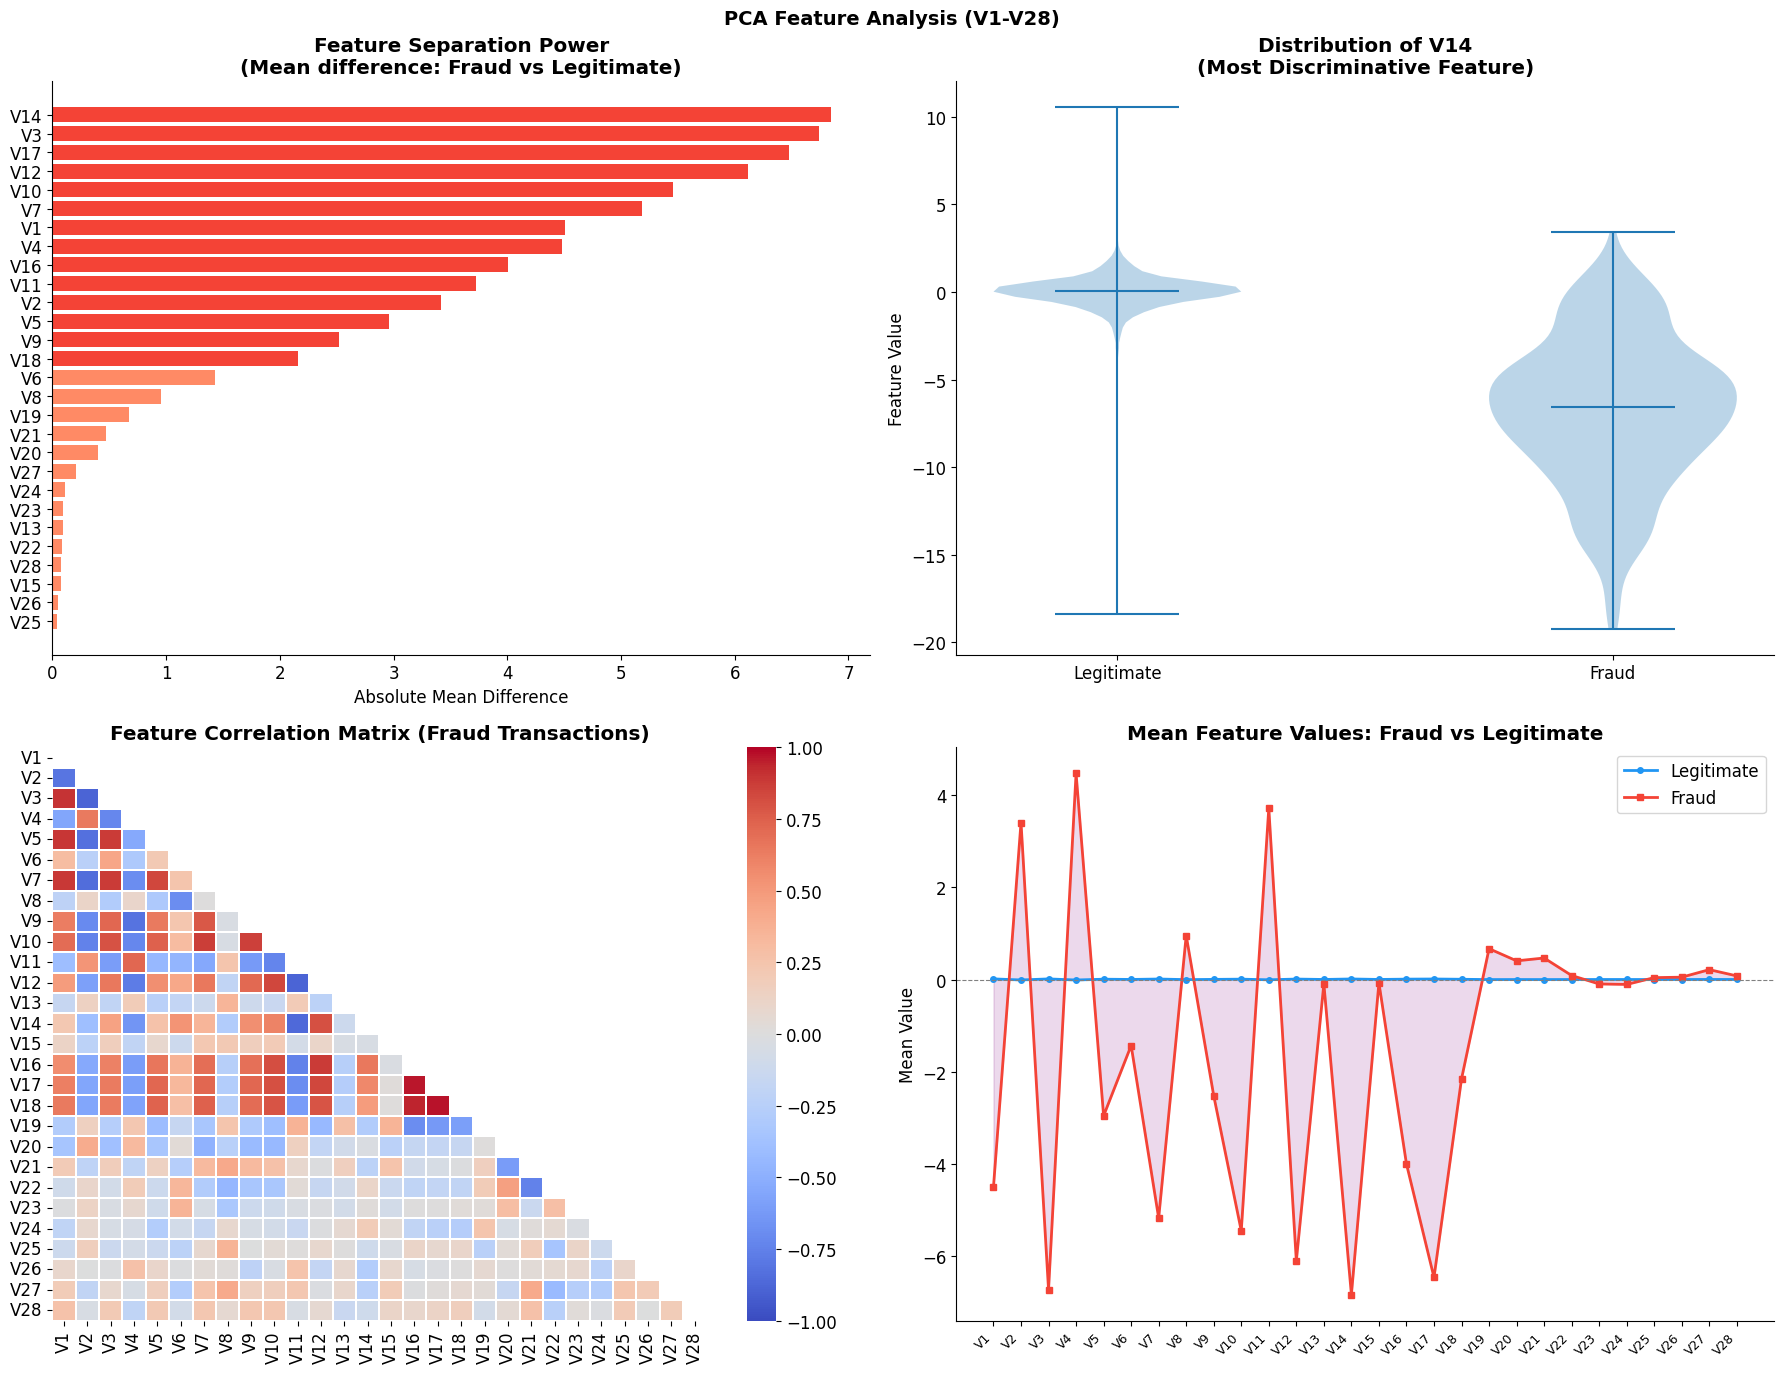


Top 5 most discriminative features for fraud detection:
  1. V14 - separation power: 6.8476
  2. V3 - separation power: 6.7425
  3. V17 - separation power: 6.4742
  4. V12 - separation power: 6.1127
  5. V10 - separation power: 5.4609


In [9]:
# PCA Feature Analysis (V1-V28)
print("PCA FEATURE ANALYSIS (V1 to V28)")
print()
print("V1 to V28 are the result of PCA transformation applied to original")
print("transaction features to protect cardholder privacy.")
print("Higher absolute values in these features indicate unusual transaction behavior.")
print()

v_features = [f"V{i}" for i in range(1, 29)]

print("Feature Statistics Summary:")
stats = df[v_features].describe().T[["mean", "std", "min", "max"]]
stats["abs_mean"] = df[v_features].abs().mean()
stats = stats.sort_values("abs_mean", ascending=False)
print(stats.head(10))

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

feature_means_legit = df[df["Class"] == 0][v_features].mean()
feature_means_fraud = df[df["Class"] == 1][v_features].mean()
diff = (feature_means_fraud - feature_means_legit).abs().sort_values(ascending=False)

axes[0, 0].barh(diff.index, diff.values, color=["#F44336" if v > diff.median() 
                else "#FF8A65" for v in diff.values])
axes[0, 0].set_title("Feature Separation Power\n(Mean difference: Fraud vs Legitimate)", 
                       fontweight="bold")
axes[0, 0].set_xlabel("Absolute Mean Difference")
axes[0, 0].invert_yaxis()

top_features = diff.head(6).index.tolist()
for i, feature in enumerate(top_features[:4]):
    ax = axes[0, 1] if i == 0 else None

axes[0, 1].violinplot([df[df["Class"] == 0][top_features[0]].values,
                        df[df["Class"] == 1][top_features[0]].values],
                       positions=[1, 2], showmedians=True)
axes[0, 1].set_xticks([1, 2])
axes[0, 1].set_xticklabels(["Legitimate", "Fraud"])
axes[0, 1].set_title(f"Distribution of {top_features[0]}\n(Most Discriminative Feature)",
                       fontweight="bold")
axes[0, 1].set_ylabel("Feature Value")

corr_fraud = df[df["Class"] == 1][v_features].corr()
mask = np.triu(np.ones_like(corr_fraud, dtype=bool))
sns.heatmap(corr_fraud, mask=mask, ax=axes[1, 0], cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.1, annot=False)
axes[1, 0].set_title("Feature Correlation Matrix (Fraud Transactions)", fontweight="bold")

fraud_means = df[df["Class"] == 1][v_features].mean()
legit_means = df[df["Class"] == 0][v_features].mean()
x = range(len(v_features))
axes[1, 1].plot(x, legit_means.values, color="#2196F3", 
                linewidth=2, marker="o", markersize=4, label="Legitimate")
axes[1, 1].plot(x, fraud_means.values, color="#F44336",
                linewidth=2, marker="s", markersize=4, label="Fraud")
axes[1, 1].fill_between(x, legit_means.values, fraud_means.values, alpha=0.15, color="purple")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(v_features, rotation=45, ha="right", fontsize=9)
axes[1, 1].set_title("Mean Feature Values: Fraud vs Legitimate", fontweight="bold")
axes[1, 1].set_ylabel("Mean Value")
axes[1, 1].legend()
axes[1, 1].axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.suptitle("PCA Feature Analysis (V1-V28)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/feature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("Top 5 most discriminative features for fraud detection:")
for i, (feat, val) in enumerate(diff.head(5).items(), 1):
    print(f"  {i}. {feat} - separation power: {val:.4f}")

OUTLIER AND ANOMALY ANALYSIS

Extreme Value Transactions (Amount > 99th percentile):
  99th percentile threshold: $1018.97
  Transactions above threshold: 2,838
  Fraud among extreme transactions: 9
  Fraud rate among extreme transactions: 0.3171%
  Overall fraud rate: 0.1667%

Statistical Outliers using IQR method:
  Amount: 18,802 outliers, 63 fraud cases (0.34% fraud rate)
  V1: 1,949 outliers, 87 fraud cases (4.46% fraud rate)
  V2: 4,430 outliers, 116 fraud cases (2.62% fraud rate)
  V3: 738 outliers, 148 fraud cases (20.05% fraud rate)
  V4: 469 outliers, 165 fraud cases (35.18% fraud rate)
  V10: 3,095 outliers, 296 fraud cases (9.56% fraud rate)
  V11: 144 outliers, 118 fraud cases (81.94% fraud rate)
  V12: 1,285 outliers, 326 fraud cases (25.37% fraud rate)
  V14: 2,333 outliers, 385 fraud cases (16.5% fraud rate)
  V17: 1,419 outliers, 329 fraud cases (23.19% fraud rate)


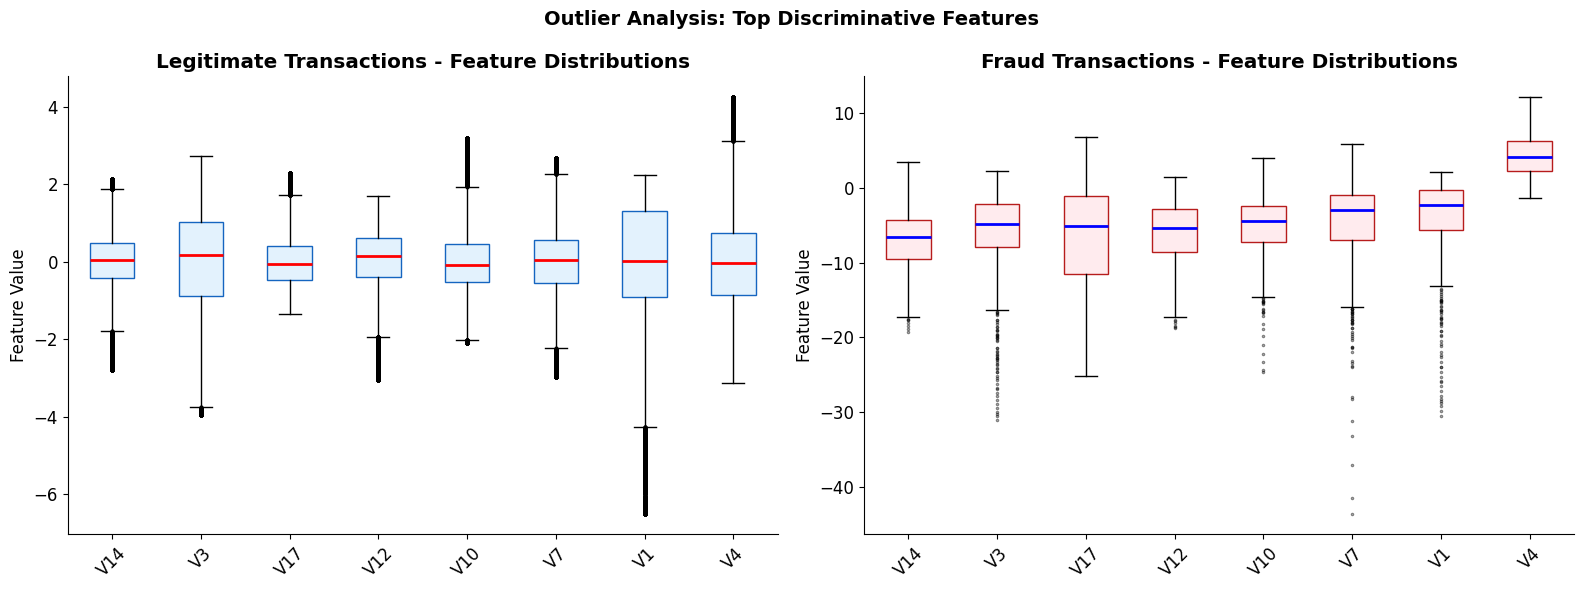

In [10]:
# Outlier and Anomaly Analysis
print("OUTLIER AND ANOMALY ANALYSIS")
print()

print("Extreme Value Transactions (Amount > 99th percentile):")
threshold_99 = df["Amount"].quantile(0.99)
extreme = df[df["Amount"] > threshold_99]
print(f"  99th percentile threshold: ${threshold_99:.2f}")
print(f"  Transactions above threshold: {len(extreme):,}")
print(f"  Fraud among extreme transactions: {extreme['Class'].sum()}")
print(f"  Fraud rate among extreme transactions: {round(extreme['Class'].mean()*100, 4)}%")
print(f"  Overall fraud rate: {round(df['Class'].mean()*100, 4)}%")

print()
print("Statistical Outliers using IQR method:")
for feature in ["Amount"] + [f"V{i}" for i in [1, 2, 3, 4, 10, 11, 12, 14, 17]]:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    outliers = df[(df[feature] < lower) | (df[feature] > upper)]
    fraud_in_outliers = outliers["Class"].sum()
    print(f"  {feature}: {len(outliers):,} outliers, {fraud_in_outliers} fraud cases "
          f"({round(fraud_in_outliers/len(outliers)*100 if len(outliers) > 0 else 0, 2)}% fraud rate)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_disc = diff.head(8).index.tolist()
data_to_plot = [df[df["Class"] == 0][feat].clip(
    df[feat].quantile(0.01), df[feat].quantile(0.99)).values for feat in top_disc]
bp = axes[0].boxplot(data_to_plot, labels=top_disc, patch_artist=True,
                      boxprops=dict(facecolor="#E3F2FD", color="#1565C0"),
                      medianprops=dict(color="red", linewidth=2),
                      flierprops=dict(marker=".", alpha=0.3, markersize=3))
axes[0].set_title("Legitimate Transactions - Feature Distributions", fontweight="bold")
axes[0].set_ylabel("Feature Value")
axes[0].tick_params(axis="x", rotation=45)

data_to_plot_fraud = [df[df["Class"] == 1][feat].values for feat in top_disc]
bp2 = axes[1].boxplot(data_to_plot_fraud, labels=top_disc, patch_artist=True,
                       boxprops=dict(facecolor="#FFEBEE", color="#B71C1C"),
                       medianprops=dict(color="blue", linewidth=2),
                       flierprops=dict(marker=".", alpha=0.5, markersize=3))
axes[1].set_title("Fraud Transactions - Feature Distributions", fontweight="bold")
axes[1].set_ylabel("Feature Value")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Outlier Analysis: Top Discriminative Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/outlier_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Key Findings and Interview Answers
print("KEY FINDINGS SUMMARY")
print()

total = len(df)
fraud_count = df["Class"].sum()
fraud_pct = df["Class"].mean() * 100
fraud_median_amt = df[df["Class"] == 1]["Amount"].median()
legit_median_amt = df[df["Class"] == 0]["Amount"].median()
peak_hour = hourly_fraud_rate.idxmax()
top_feat = diff.index[0]

print("1. Class Imbalance")
print(f"   Dataset has {fraud_pct:.4f}% fraud - extreme imbalance of {round((total-fraud_count)/fraud_count)}:1")
print("   Solution: SMOTE oversampling + class-weighted models + threshold optimization")
print()
print("2. Transaction Amount Patterns")
print(f"   Fraud median amount ${fraud_median_amt:.2f} vs Legitimate ${legit_median_amt:.2f}")
print("   Fraudsters prefer smaller amounts to stay under detection thresholds")
print()
print("3. Time Patterns")
print(f"   Peak fraud activity at hour {peak_hour}:00")
print("   Time-of-day is a strong signal for fraud prediction")
print()
print("4. Most Discriminative Features")
for i, (feat, val) in enumerate(diff.head(5).items(), 1):
    print(f"   {i}. {feat} with separation power of {val:.4f}")
print()
print("5. Feature Engineering Opportunities")
print("   Transaction velocity (how many transactions in last N minutes)")
print("   Amount deviation from user's typical spending")
print("   Time since last transaction")
print("   Rolling average amount per hour")
print()
print("6. Model Strategy")
print("   Cannot use accuracy as metric - baseline 99.83% by predicting all legitimate")
print("   Must optimize for AUC-ROC, F1-Score, Recall (catching fraud matters most)")
print("   False negative (missed fraud) costs more than false positive (false alarm)")
print("   Threshold must be tuned based on business cost matrix not default 0.5")

KEY FINDINGS SUMMARY

1. Class Imbalance
   Dataset has 0.1667% fraud - extreme imbalance of 599:1
   Solution: SMOTE oversampling + class-weighted models + threshold optimization

2. Transaction Amount Patterns
   Fraud median amount $9.82 vs Legitimate $22.00
   Fraudsters prefer smaller amounts to stay under detection thresholds

3. Time Patterns
   Peak fraud activity at hour 2:00
   Time-of-day is a strong signal for fraud prediction

4. Most Discriminative Features
   1. V14 with separation power of 6.8476
   2. V3 with separation power of 6.7425
   3. V17 with separation power of 6.4742
   4. V12 with separation power of 6.1127
   5. V10 with separation power of 5.4609

5. Feature Engineering Opportunities
   Transaction velocity (how many transactions in last N minutes)
   Amount deviation from user's typical spending
   Time since last transaction
   Rolling average amount per hour

6. Model Strategy
   Cannot use accuracy as metric - baseline 99.83% by predicting all legitima